Open a Open-X Embodiment (OxE) dataset

* Goal:
    * Open OxE dataset.
    * Inspect its content.
    * Plot: images, time series of actions, etc.
    * Save a subpart of it (5%) in hdf5 format.
    * Open hdf5 saved file -> Explore whether the format is the same as TFDS format.

* environment: oxe_download

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import numpy as np

import tensorflow_datasets as tfds
import tensorflow as tf

In [2]:
builder = tfds.builder_from_directory(
    builder_dir="gs://gresearch/robotics/bridge/0.1.0"
)

dataset = builder.as_dataset(split="train")
print(f"Data size on disk: {builder.info.dataset_size / 1e9:.2f} GB")    # GB

Data size on disk: 416.07 GB


In [4]:
# Metadata — features, splits, size, description
print("====================================================")
print(f"Dataset info:\n\n{builder.info}")

# Just the feature spec (very useful for Bridge since it's a nested dict:
# observation/action/reward/etc. per step, grouped into episodes)
print("====================================================")
print(f"Dataset info features:\n\n{builder.info.features}")

# Pull one episode and look at its structure
for episode in dataset.take(1):
    print(episode.keys())
    for step in episode["steps"].take(1):
        print(step.keys())
        print(step["observation"].keys())
        print(step["action"])

tfds.core.DatasetInfo(
    name='bridge',
    full_name='bridge/0.1.0',
    description="""
    WidowX interacting with toy kitchens
    """,
    homepage='https://rail-berkeley.github.io/bridgedata/',
    data_dir='gs://gresearch/robotics/bridge/0.1.0',
    file_format=tfrecord,
    download_size=Unknown size,
    dataset_size=387.49 GiB,
    features=FeaturesDict({
        'steps': Dataset({
            'action': FeaturesDict({
                'open_gripper': bool,
                'rotation_delta': Tensor(shape=(3,), dtype=float32),
                'terminate_episode': float32,
                'world_vector': Tensor(shape=(3,), dtype=float32),
            }),
            'is_first': bool,
            'is_last': bool,
            'is_terminal': bool,
            'observation': FeaturesDict({
                'image': Image(shape=(480, 640, 3), dtype=uint8),
                'natural_language_embedding': Tensor(shape=(512,), dtype=float32),
                'natural_language_instruction':

2026-08-25 14:57:54.420873: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


dict_keys(['steps'])
dict_keys(['action', 'is_first', 'is_last', 'is_terminal', 'observation', 'reward'])
dict_keys(['image', 'natural_language_embedding', 'natural_language_instruction', 'state'])
{'open_gripper': <tf.Tensor: shape=(), dtype=bool, numpy=True>, 'rotation_delta': <tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 6.077167e-07, -1.193009e-07,  1.308389e-07], dtype=float32)>, 'terminate_episode': <tf.Tensor: shape=(), dtype=float32, numpy=0.0>, 'world_vector': <tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.9514002e-10, 8.0674190e-11, 2.9859176e-10], dtype=float32)>}


2026-08-25 14:58:36.873730: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-25 15:02:45.668848: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
print(builder.info.features["steps"]["observation"].keys())

dict_keys(['natural_language_embedding', 'state', 'image', 'natural_language_instruction'])


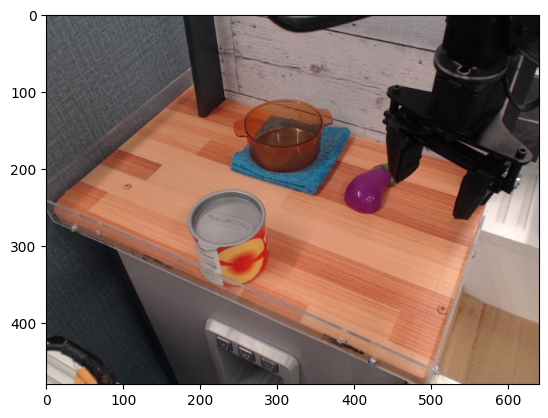

In [17]:
for episode in dataset.take(1):
    for step in episode["steps"].take(1):
        img = step["observation"]["image"]
        plt.imshow(img.numpy())
        plt.show()

In [15]:
# if tabular inspection is desired
df = tfds.as_dataframe(dataset.take(5), builder.info)

AttributeError: The '.style' accessor requires jinja2

### Split dataset

* dataset.save() vs builder.download_and_prepare():
    * dataset.save() is a much lighter, TF-native way to freeze a specific slice or transformed pipeline to disk quickly, but it loses TFDS-level metadata like dataset_size, feature descriptions, citation, etc.
    * download_and_prepare() gives the whole  dataset back in TFDS's own format (portable, versioned, reloadable with all metadata).

In [ ]:
path_data = str(Path.cwd().parent / "data/bridge_subset")
# dataset = builder.as_dataset(split="train[:1%]")   # only ~1% of episodes
# subset = dataset.take(2)  # first N episodes. Return a lazy object: nothing is loaded until iteration.

# subset.save(path_data)  # tf.data.Dataset.save

# reload later
reloaded = tf.data.Dataset.load(path_data)

In [ ]:
# transform into hdf5 format. Useful for uploading with an environment without tensorflow.
with h5py.File(f"{path_data}/bridge_subset.h5", "w") as f:
    for i, episode in enumerate(subset):
        grp = f.create_group(f"episode_{i}")
        steps = list(episode["steps"])
        grp.create_dataset(
            "images",
            data=np.stack([s["observation"]["image"].numpy() for s in steps])
        )
        grp.create_dataset(
            "actions",
            data=np.stack([s["action"].numpy() for s in steps])
        )

KeyError: 'image_0'